# Model Evaluation and Diagnostics

After building and refining regression models, it is essential to evaluate how well the model performs and whether it satisfies key statistical assumptions.

While performance metrics such as R-squared and RMSE provide a quantitative measure of accuracy, they do not fully explain whether the model is reliable or unbiased.

Model diagnostics help answer important questions:

- Are prediction errors randomly distributed?
- Does the model systematically overestimate or underestimate?
- Do residuals follow a normal distribution?
- Are there patterns indicating missing relationships in the model?

In this notebook, we perform a detailed evaluation of the regression model using:

- Residual analysis
- Q-Q plots for normality testing
- Actual vs predicted comparisons
- Performance metrics (R² and RMSE)

These analyses provide deeper insight into model behavior and help validate whether the model is suitable for real-world deployment.

## Import Required Libraries

In this section, we import libraries required for:

- Data manipulation and numerical computation
- Model building and evaluation
- Visualization of residuals and predictions
- Statistical analysis for diagnostic plots

These tools allow us to thoroughly assess model performance.

In [1]:
# Import pandas for handling structured data in DataFrame format
import pandas as pd

# Import numpy for numerical operations such as arrays and mathematical calculations
import numpy as np

# Import matplotlib for creating basic visualizations
import matplotlib.pyplot as plt

# Import seaborn for enhanced statistical visualizations
import seaborn as sns


# Import LinearRegression model for training regression model
from sklearn.linear_model import LinearRegression

# Import evaluation metrics to measure model performance
from sklearn.metrics import mean_squared_error, r2_score

# Import scipy.stats for generating Q-Q plots and statistical analysis
import scipy.stats as stats

# Set a clean visual style for all plots
sns.set(style="whitegrid")

## Load Dataset and Sort Chronologically

We load the normalized dataset produced by notebook 02, parse dates with `dayfirst=True` (the source format is `dd/mm/yyyy`), and sort by date so the train/test split below is just a positional slice. We also lowercase column names for robustness and convert `functioning_day` (`Yes`/`No`) into a 0/1 integer so it is usable numerically by the diagnostic regression.

In [ ]:
# ── Load and Prepare Dataset ──────────────────────────────────
df = pd.read_csv("seoul_bike_sharing_converted_normalized.csv")                 # load normalized dataset produced by notebook 02
df.columns = df.columns.str.lower()                                             # lowercase column names for robustness
df['functioning_day'] = (df['functioning_day'].str.lower() == 'yes').astype(int)  # encode Yes/No as 1/0 so models can use it numerically
df['date'] = pd.to_datetime(df['date'], dayfirst=True)                          # parse date strings as dd/mm/yyyy
df = df.sort_values('date').reset_index(drop=True)                              # sort chronologically and reset index for positional slicing


## Define Features and Target

We separate the dataset into a feature matrix `X` and target vector `y`. We drop both the target (`rented_bike_count`) and the raw `date` column from `X` — date's temporal signal is already encoded in `year`, `month`, and `day_of_week`, so leaving it in would be redundant (and `LinearRegression` cannot consume `datetime64` values directly).

In [ ]:
# ── Define Features and Target ────────────────────────────────
X = df.drop(columns=['rented_bike_count', 'date'])    # drop target and raw date (date already encoded in year/month/day_of_week)
y = df['rented_bike_count']                           # target: hourly bike rentals (normalized)


## Chronological Train/Test Split

We split chronologically (earliest 80% → train, latest 20% → test) rather than randomly. A time-aware split is the honest evaluation for a forecasting workflow — it prevents the diagnostic model from peeking at future demand patterns. Because the DataFrame is already sorted by `date`, the split is a simple positional slice.

In [ ]:
# ── Chronological 80/20 Split ─────────────────────────────────
split_idx = int(len(df) * 0.8)                                # index of last training row (first 80%)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]      # earliest 80% of features → train, latest 20% → test
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]      # mirror the same positional slice for the target


## Train Regression Model

We train a linear regression model using the training data. This model learns the relationship between predictor variables and bike demand.

In [5]:
# Initialize linear regression model
model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)

# Generate predictions on test dataset
y_pred = model.predict(X_test)

## Residual Analysis

Residuals represent the difference between actual and predicted values.

Residual = Actual Value - Predicted Value

A well-behaved model should have:

- Residuals centered around zero
- No clear patterns when plotted against predictions
- Constant variance across predictions

Analyzing residuals helps identify model bias and potential issues.

In [6]:
# Calculate residuals as difference between actual and predicted values
residuals = y_test - y_pred

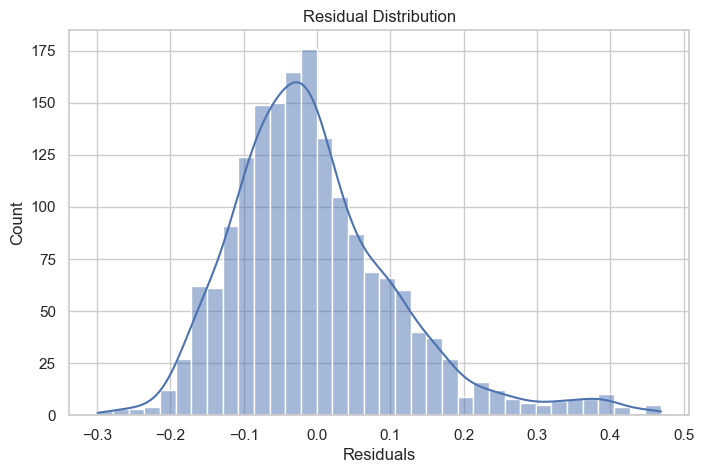

In [7]:
# Plot distribution of residuals

# Create figure with specified size
plt.figure(figsize=(8,5))

# Plot histogram with density curve
sns.histplot(residuals, kde=True)

# Add title and labels
plt.title("Residual Distribution")
plt.xlabel("Residuals")

# Display plot
plt.show()

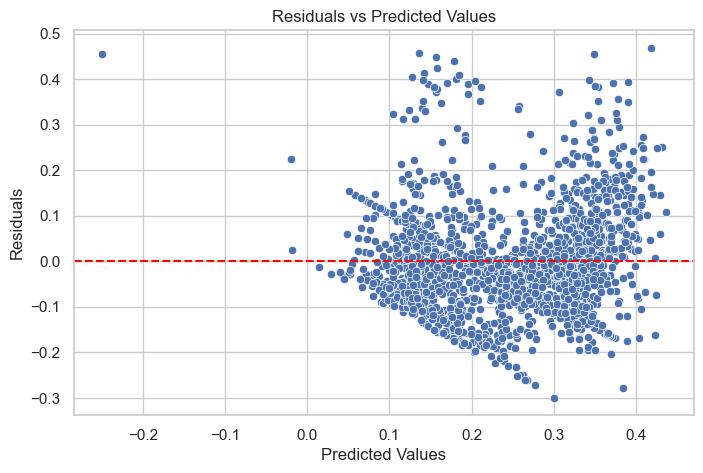

In [8]:
# Plot residuals vs predicted values

# Create figure
plt.figure(figsize=(8,5))

# Scatter plot of predicted values vs residuals
sns.scatterplot(x=y_pred, y=residuals)

# Add horizontal line at zero to detect bias
plt.axhline(0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

# Show plot
plt.show()

## Q-Q Plot (Normality Check)

A Q-Q (quantile-quantile) plot compares the distribution of residuals with a theoretical normal distribution.

If residuals are normally distributed:

- Points will lie approximately along a straight diagonal line

Deviations from this line indicate:

- Skewness
- Heavy tails
- Model misspecification

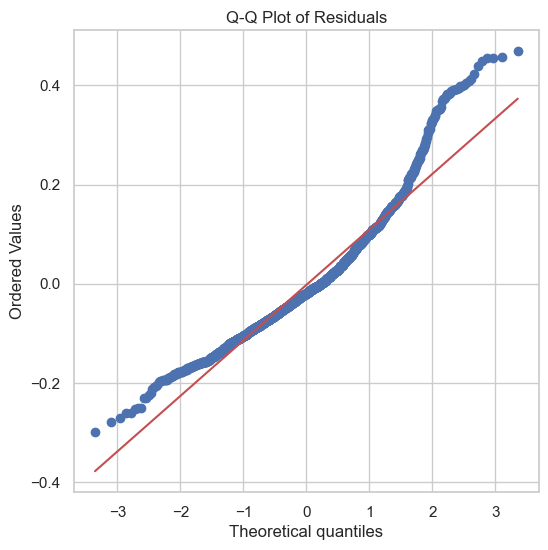

In [9]:
# Create Q-Q plot to assess normality of residuals

# Set figure size
plt.figure(figsize=(6,6))

# Generate Q-Q plot using scipy
stats.probplot(residuals, dist="norm", plot=plt)

# Add title
plt.title("Q-Q Plot of Residuals")

# Display plot
plt.show()

## Actual vs Predicted Values

This visualization compares actual values with predicted values.

A well-performing model should produce points close to the diagonal line, indicating accurate predictions.

Large deviations from the line indicate prediction errors.

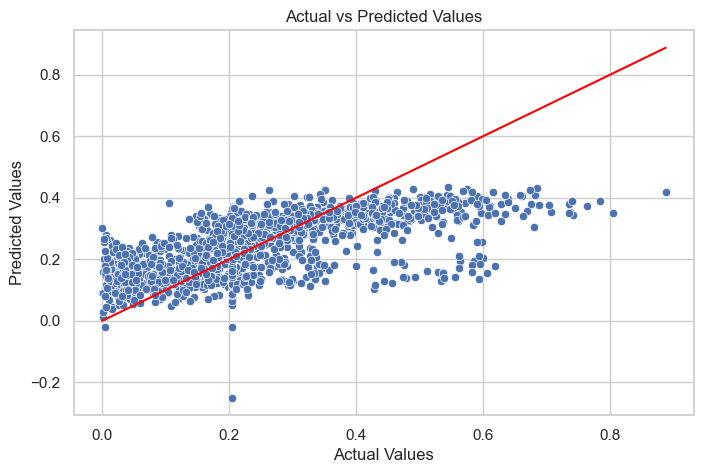

In [10]:
# Plot actual vs predicted values

# Create figure
plt.figure(figsize=(8,5))

# Scatter plot comparing actual and predicted values
sns.scatterplot(x=y_test, y=y_pred)

# Add diagonal reference line representing perfect prediction
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

# Display plot
plt.show()

## Model Performance Metrics

We evaluate the model using:

- R-squared (R²): Measures how much variance is explained
- RMSE: Measures average prediction error magnitude

These metrics provide a quantitative assessment of model accuracy.

In [11]:
# Calculate R-squared value
r2 = r2_score(y_test, y_pred)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print results
print("R-squared:", r2)
print("RMSE:", rmse)

R-squared: 0.43021755002815776
RMSE: 0.1153038806188708


## Interpretation

From the diagnostic analysis:

- Residual plots help detect bias and heteroscedasticity
- Q-Q plots assess whether residuals follow normal distribution
- Actual vs predicted plots show prediction accuracy visually

If strong patterns or deviations are observed, it may indicate:

- Missing variables
- Non-linear relationships
- Model underfitting or overfitting

These insights are crucial for refining and validating predictive models.

---

## Author & Acknowledgment

**Author:**  
Deepan Mehta  

**GitHub Profile:**  
https://github.com/deepan-mehta-analytics

This notebook focuses on evaluating regression model performance using statistical diagnostics and visualization techniques.

The concepts applied here are inspired by foundational regression analysis principles and IBM Skills Network instructional materials.

Special acknowledgment is given to:

- Yan Luo  
- Jeff Grossman  
- Rav Ahuja et al. at the IBM Skills Network  

---

## Project Context

This notebook represents the model validation stage in the pipeline:

- Data Collection  
- Data Wrangling  
- EDA  
- Model Development  
- Model Evaluation  

---

## Notes

All code and explanations have been independently structured to emphasize clarity, interpretability, and real-world applicability.

---